In [14]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
os.makedirs("data/processed", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)


In [15]:
import pandas as pd

filename = "ks-projects-201801.csv"
try:
    df = pd.read_csv(filename, encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(filename, encoding="latin1")

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (30454, 15)


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12,0.0,failed,0.0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 4:43,2421.0,failed,15.0,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 0:20,220.0,failed,3.0,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 3:24,1.0,failed,1.0,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 8:35,1283.0,canceled,14.0,US,1283.0,1283.0,19500.00


##Rebuild the clean binary target

In [16]:
TARGET = "state"

binary_df = df[df[TARGET].isin(["successful", "failed"])].copy()
binary_df["target"] = (binary_df[TARGET] == "successful").astype(int)

print(f"Rows kept: {len(binary_df):,} ({len(binary_df)/len(df)*100:.1f}% of original)")
binary_df["target"].value_counts(normalize=True).round(3)

Rows kept: 26,715 (87.7% of original)


,proportion
target,
0,0.591
1,0.409


## Drop unusable / corrupt rows

In [17]:
binary_df["launched_dt"] = pd.to_datetime(binary_df["launched"], errors="coerce")
binary_df["deadline_dt"] = pd.to_datetime(binary_df["deadline"], errors="coerce")

before = len(binary_df)

bad_epoch = binary_df["launched_dt"].dt.year <= 1971
bad_order = binary_df["deadline_dt"] < binary_df["launched_dt"]
bad_goal = binary_df["usd_goal_real"] <= 0

binary_df = binary_df[~(bad_epoch | bad_order | bad_goal)].copy()

print(f"Dropped {before - len(binary_df):,} corrupt rows ({(before - len(binary_df))/before*100:.3f}%)")
print(f"Remaining rows: {len(binary_df):,}")


Dropped 0 corrupt rows (0.000%)
Remaining rows: 26,715


## Date-based features

In [18]:
binary_df["campaign_duration"] = (
    binary_df["deadline_dt"] - binary_df["launched_dt"]
).dt.days

binary_df["launch_month"] = binary_df["launched_dt"].dt.month
binary_df["launch_weekday"] = binary_df["launched_dt"].dt.day_name()
binary_df["launch_quarter"] = binary_df["launched_dt"].dt.quarter

binary_df[["campaign_duration", "launch_month", "launch_weekday", "launch_quarter"]].describe(include="all")


,campaign_duration,launch_month,launch_weekday,launch_quarter
count,26715.000000,26715.000000,26715,26715.000000
unique,NaN,NaN,7,NaN
top,NaN,NaN,Tuesday,NaN
freq,NaN,NaN,5455,NaN
mean,32.958787,6.427251,NaN,2.482164
std,12.722665,3.295164,NaN,1.090675
min,0.000000,1.000000,NaN,1.000000
25%,29.000000,4.000000,NaN,2.000000
50%,29.000000,6.000000,NaN,2.000000
75%,35.000000,9.000000,NaN,3.000000


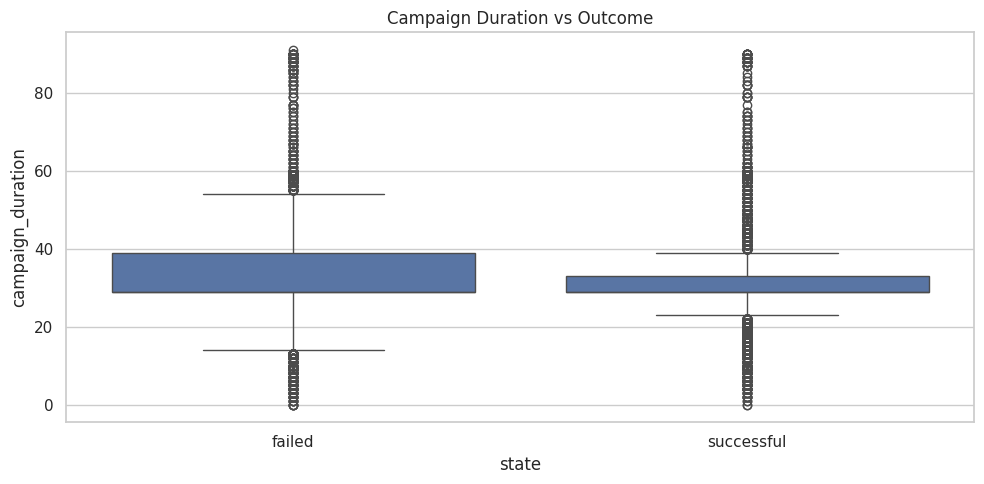

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure the output directory exists
os.makedirs("reports/figures", exist_ok=True)

plt.figure(figsize=(10, 5))
sns.boxplot(data=binary_df, x=TARGET, y="campaign_duration")
plt.title("Campaign Duration vs Outcome")
plt.tight_layout()
plt.savefig("reports/figures/duration_vs_outcome.png", dpi=300, bbox_inches="tight")
plt.show()

## Goal Log

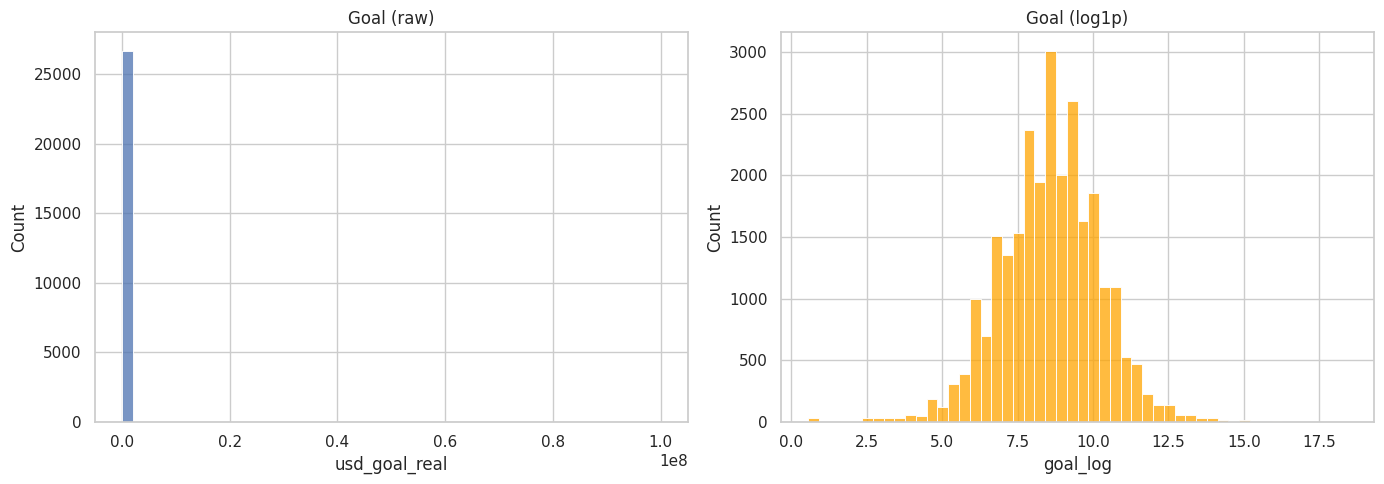

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure the output directory exists
os.makedirs("reports/figures", exist_ok=True)

binary_df["goal_log"] = np.log1p(binary_df["usd_goal_real"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(binary_df["usd_goal_real"], bins=50, ax=axes[0])
axes[0].set_title("Goal (raw)")
sns.histplot(binary_df["goal_log"], bins=50, ax=axes[1], color="orange")
axes[1].set_title("Goal (log1p)")
plt.tight_layout()
plt.savefig("reports/figures/goal_log_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

##Outcome-adjacent features

In [21]:
binary_df["funding_ratio"] = (
    binary_df["usd_pledged_real"] / binary_df["usd_goal_real"].replace(0, np.nan)
)
binary_df["avg_pledge"] = (
    binary_df["usd_pledged_real"] / binary_df["backers"].replace(0, np.nan)
)

binary_df[["funding_ratio", "avg_pledge"]].describe()


,funding_ratio,avg_pledge
count,26715.000000,23698.000000
mean,3.424019,73.701783
std,165.713693,115.913519
min,0.000000,0.520000
25%,0.008333,25.706751
50%,0.208092,49.055789
75%,1.098873,85.201127
max,22603.000000,4371.800000


##Category frequency encoding

In [22]:
category_freq = binary_df["category"].value_counts(normalize=True)
binary_df["category_frequency"] = binary_df["category"].map(category_freq)

binary_df[["category", "category_frequency"]].drop_duplicates().sort_values(
    "category_frequency", ascending=False
).head(10)


,category,category_frequency
31,Product Design,0.054950
37,Documentary,0.042860
3,Music,0.036047
14,Tabletop Games,0.035411
96,Shorts,0.034700
6,Food,0.030807
79,Video Games,0.027962
57,Film & Video,0.027587
56,Fiction,0.024144
10,Nonfiction,0.023358


## Country success rate

In [23]:
from sklearn.model_selection import train_test_split

feature_cols_preview = [
    "main_category", "category", "currency", "country", "usd_goal_real",
    "goal_log", "campaign_duration", "launch_month", "launch_weekday",
    "launch_quarter", "category_frequency",
]

train_df, test_df = train_test_split(
    binary_df,
    test_size=0.2,
    stratify=binary_df["target"],
    random_state=RANDOM_STATE,
)

# Compute country success rate on TRAIN ONLY
country_success_rate = train_df.groupby("country")["target"].mean()
global_success_rate = train_df["target"].mean()  # fallback for unseen countries

train_df = train_df.copy()
test_df = test_df.copy()
train_df["country_success_rate"] = train_df["country"].map(country_success_rate)
test_df["country_success_rate"] = (
    test_df["country"].map(country_success_rate).fillna(global_success_rate)
)

print(f"Train rows: {len(train_df):,}  |  Test rows: {len(test_df):,}")
train_df[["country", "country_success_rate"]].drop_duplicates().sort_values(
    "country_success_rate", ascending=False
).head(10)


Train rows: 21,372  |  Test rows: 5,343


,country,country_success_rate
13048,"N,0""",0.714286
756,HK,0.500000
24070,US,0.424338
11027,GB,0.417501
18882,SG,0.413793
19645,IE,0.372549
22678,CA,0.352500
29757,NZ,0.343284
23,NO,0.333333
27398,AU,0.298795


##Assemble the final pre-launch feature set

In [24]:
safe_feature_cols = [
    "main_category", "category", "currency", "country",
    "usd_goal_real", "goal_log", "campaign_duration",
    "launch_month", "launch_weekday", "launch_quarter",
    "category_frequency", "country_success_rate",
]

analysis_only_cols = ["funding_ratio", "avg_pledge"]  # keep for SHAP/pattern-mining later, not Day 4 training

X_train = train_df[safe_feature_cols]
y_train = train_df["target"]
X_test = test_df[safe_feature_cols]
y_test = test_df["target"]

print("X_train:", X_train.shape, " X_test:", X_test.shape)
X_train.head()


X_train: (21372, 12)  X_test: (5343, 12)


,main_category,category,currency,country,usd_goal_real,goal_log,campaign_duration,launch_month,launch_weekday,launch_quarter,category_frequency,country_success_rate
24070,Publishing,Children's Books,USD,US,4300.0,8.366603,29,8,Wednesday,3,0.018342,0.424338
10943,Design,Product Design,USD,US,10000.0,9.210440,34,1,Wednesday,1,0.054950,0.424338
25076,Music,Pop,USD,US,50000.0,10.819798,59,1,Monday,1,0.009059,0.424338
15766,Technology,Hardware,USD,US,135000.0,11.813037,29,10,Monday,4,0.009358,0.424338
15750,Film & Video,Webseries,USD,US,20000.0,9.903538,27,8,Thursday,3,0.015085,0.424338


### Save processed data for Day 4

In [25]:
train_df.to_csv("data/processed/train_features.csv", index=False)
test_df.to_csv("data/processed/test_features.csv", index=False)

print("Saved:")
print(" - data/processed/train_features.csv", train_df.shape)
print(" - data/processed/test_features.csv ", test_df.shape)

Saved:
 - data/processed/train_features.csv (21372, 27)
 - data/processed/test_features.csv  (5343, 27)
